# Пример обучения модели градиентного бустинга

### Настройка проекта и загрузка данных

In [1]:
import pandas as pd
# импортируем нужный класс для задачи регрессии
from xgboost import XGBRegressor
# импортируем метрику для оценки качества модели
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# Импортируем нужный класс для задачи регрессии
from lightgbm import LGBMRegressor
import pandas as pd
# Импортируем нужный класс для задачи регрессии
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.tree import plot_tree
import warnings
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
import time
from sklearn.ensemble import StackingRegressor

In [4]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

In [5]:
RANDOM_STATE = 42

In [6]:
data_path: str = 'https://code.s3.yandex.net/datasets/ds_s16t3_ames_housing.csv'

df = pd.read_csv(data_path)
df.head()

,Overall Qual,Gr Liv Area,Neighborhood,Bsmt Qual,Total Bsmt SF,Kitchen Qual,1st Flr SF,2nd Flr SF,Exter Qual,Year Built,Year Remod/Add,Lot Area,SalePrice
0,6,1656,NAmes,TA,1080.0,TA,1656,0,TA,1960,1960,31770,215000
1,5,896,NAmes,TA,882.0,TA,896,0,TA,1961,1961,11622,105000
2,6,1329,NAmes,TA,1329.0,Gd,1329,0,TA,1958,1958,14267,172000
3,7,2110,NAmes,TA,2110.0,Ex,2110,0,Gd,1968,1968,11160,244000
4,5,1629,Gilbert,Gd,928.0,TA,928,701,TA,1997,1998,13830,189900


In [7]:
# список всех категориальных признаков
cat_columns = ["Neighborhood", "Bsmt Qual", "Kitchen Qual", "Exter Qual"]

for col in cat_columns:
	# приведение всех категориальных признаков к pd.categorical
	df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Overall Qual    2850 non-null   int64   
 1   Gr Liv Area     2850 non-null   int64   
 2   Neighborhood    2850 non-null   category
 3   Bsmt Qual       2850 non-null   category
 4   Total Bsmt SF   2850 non-null   float64 
 5   Kitchen Qual    2850 non-null   category
 6   1st Flr SF      2850 non-null   int64   
 7   2nd Flr SF      2850 non-null   int64   
 8   Exter Qual      2850 non-null   category
 9   Year Built      2850 non-null   int64   
 10  Year Remod/Add  2850 non-null   int64   
 11  Lot Area        2850 non-null   int64   
 12  SalePrice       2850 non-null   int64   
dtypes: category(4), float64(1), int64(8)
memory usage: 213.5 KB


### Разделение на выборки

In [6]:
X = df.drop(columns='SalePrice')
y = pd.Series(df['SalePrice'], name='target')
display(X.head(), y)

,Overall Qual,Gr Liv Area,Neighborhood,Bsmt Qual,Total Bsmt SF,Kitchen Qual,1st Flr SF,2nd Flr SF,Exter Qual,Year Built,Year Remod/Add,Lot Area
0,6,1656,NAmes,TA,1080.0,TA,1656,0,TA,1960,1960,31770
1,5,896,NAmes,TA,882.0,TA,896,0,TA,1961,1961,11622
2,6,1329,NAmes,TA,1329.0,Gd,1329,0,TA,1958,1958,14267
3,7,2110,NAmes,TA,2110.0,Ex,2110,0,Gd,1968,1968,11160
4,5,1629,Gilbert,Gd,928.0,TA,928,701,TA,1997,1998,13830


0       215000
1       105000
2       172000
3       244000
4       189900
         ...  
2845    142500
2846    131000
2847    132000
2848    170000
2849    188000
Name: target, Length: 2850, dtype: int64

In [7]:
# train-val 80% и test 20%
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)
# train 60% и validate 20%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    shuffle=True,
    random_state=42
)

### Обучение базовых моделей XGBoost

In [8]:
# инициализируем XGBRegressor с поддержкой обработки категориальных признаков
xgb_model = XGBRegressor(random_state=42, enable_categorical=True)

# обучаем модель на обучающей выборке
xgb_model.fit(X_train, y_train)

# получаем предсказания по тестовым объектам
y_pred = xgb_model.predict(X_test)

# рассчитываем значение метрики rmse
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Значение RMSE на тестовой выборке: {rmse:.2f}")

Значение RMSE на тестовой выборке: 27161.23


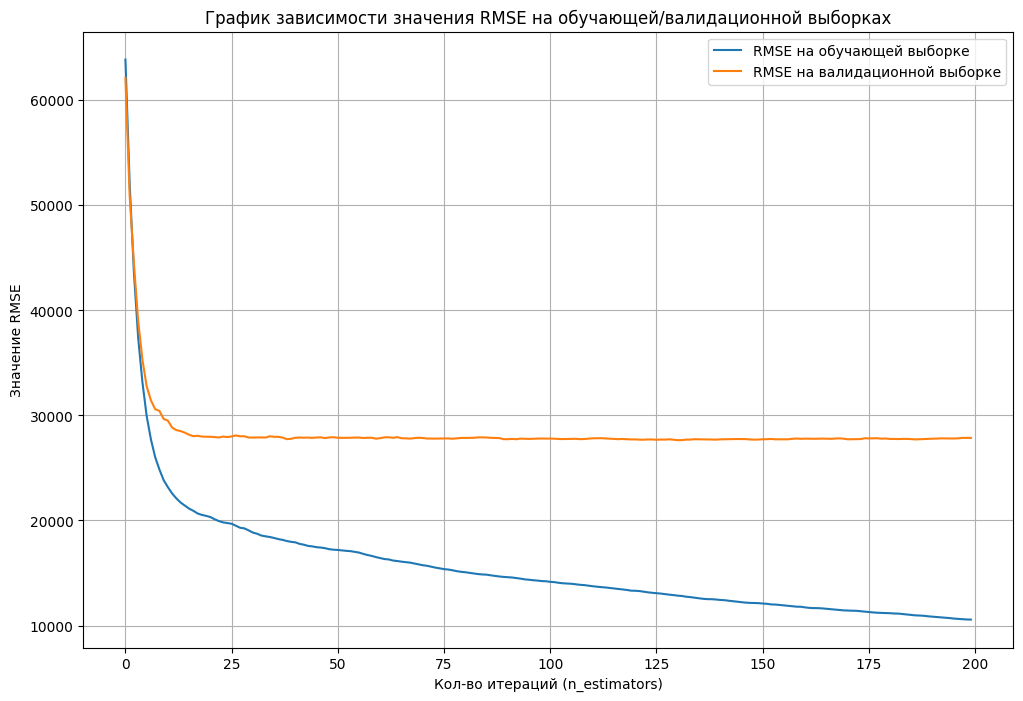

In [9]:
xgb_model = XGBRegressor(
    max_depth=3, # задаём максимальную глубину дерева
    n_estimators=200, # задаём кол-во последовательных деревьев
    learning_rate=0.3, # устанавливаем шаг обучения
    random_state=42, 
    enable_categorical=True,
    eval_metric="rmse" # задаём метрику для оценки качества обучения
)

# Обучаем модель с eval_set
xgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)], # Задаём train/val пару для оценки качества на 2-х подвыборках
    verbose=False
)

# Достаём значения метрики rmse на каждой итерации обучения
results = xgb_model.evals_result()
epochs = len(results['validation_0']['rmse'])
x = range(epochs)

# Строим график
plt.plot(x, results['validation_0']['rmse'], label='RMSE на обучающей выборке')
plt.plot(x, results['validation_1']['rmse'], label='RMSE на валидационной выборке')
plt.xlabel('Кол-во итераций (n_estimators)')
plt.ylabel('Значение RMSE')
plt.title('График зависимости значения RMSE на обучающей/валидационной выборках')
plt.legend()
plt.grid(True)
plt.show()

#### eval_set и early_stopping_rounds

In [10]:
xgb_model = XGBRegressor(
    max_depth=3, # задаём максимальную глубину дерева
    n_estimators=200, # задаём кол-во последовательных деревьев
    learning_rate=0.3, # устанавливаем шаг обучения
    random_state=42, 
    enable_categorical=True,
    eval_metric="rmse",
    reg_lambda=2, # усиливаем L2-регуляризацию весов листьев (делаем модель более «гладкой»)
    colsample_bytree=0.8, # каждое дерево видит только 80% признаков (немного стохастики для устойчивости)
)

# Обучаем модель с eval_set и early_stopping_rounds
xgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)], # Задаём train/val пару для оценки качества на 2-х подвыборках
    verbose=False
    )

# Получение предсказаний и метрики на test
y_pred = xgb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Значение RMSE на тестовой выборке: {rmse:.2f}")

Значение RMSE на тестовой выборке: 25330.89


#### Контроль переобучения

In [11]:
xgb_model = XGBRegressor(
    max_depth=3, # задаём максимальную глубину дерева
    n_estimators=200, # задаём кол-во последовательных деревьев
    random_state=42, 
    learning_rate=0.3, # устанавливаем шаг обучения
    enable_categorical=True,
    eval_metric="rmse", # задаём метрику для оценки качества обучения
    reg_lambda=2, # усиливаем L2-регуляризацию весов листьев (делаем модель более «гладкой»)
    colsample_bytree=0.8, # каждое дерево видит только 90% признаков (немного стохастики для устойчивости)
    early_stopping_rounds=50, # если 30 итераций подряд нет улучшения RMSE на val — останавливаемся
)

# Обучаем модель с eval_set и early_stopping_rounds
xgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)], # Задаём train/val пару для оценки качества на 2-х подвыборках
    verbose=False
)

print("Лучшее число деревьев (best_iteration):", xgb_model.best_iteration)

# Получение предсказаний и метрики на test
y_pred = xgb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Значение RMSE на тестовой выборке: {rmse:.2f}")

Лучшее число деревьев (best_iteration): 103
Значение RMSE на тестовой выборке: 25763.83


#### Рекомендации

**1. Базовый каркас: n_estimators, learning_rate, max_depth**

Начинайте с умеренной глубины деревьев. 
- Для табличных задач вроде Ames Housing разумный старт — это max_depth в диапазоне 2–4. 
- Слишком маленькая глубина → модель недообучается; слишком большая → почти гарантированное переобучение.

Настраивайте связку learning_rate иn_estimators.
- Чем меньше learning_rate, тем больше деревьев можно себе позволить. 
- Всегда оценивайте качество на валидации, не только на обучающей выборке.

Используйте eval_set и кривые обучения.
- Передавайте в fit пару (X_train, y_train), (X_val, y_val) и eval_metric="rmse".
- Смотрите на evals_result_: если значение RMSE на обучающей выборке падает, а на валидационной растёт — модель переобучается, стоит уменьшить
- n_estimators или max_depth либо усилить регуляризацию.

**2. Ранняя остановка (early stopping)**

Почти всегда используйте раннюю остановку.
- Это позволяет задавать n_estimators «с запасом» и не подбирать точное число деревьев руками. 
- Разумный старт — early_stopping_rounds в диапазоне 10–50, дальше можно подстраивать под размер и «шумность» валидационной выборки.

Правильно подбирайте eval_metric. 
- Это может быть как стандартная метрика ( rmse, mae, logloss, mlogloss и т. п.), так и любая другая поддерживаемая метрика или пользовательская функция оценки.

**3. Регуляризация и «ужесточение» модели**
Используйте регуляризацию, особенно на малых данных.
- При небольшом объёме данных модель легко переобучается. 
- Рекомендуется:
    - reg_lambda (L2) — начать с 1–5, при сильном переобучении — увеличить;
    - reg_alpha (L1) — начать с 0–1, добавлять при явном переобучении и «шумных» признаках;
    - gamma (min_split_loss) — попробовать 0–1, увеличивать, если деревья слишком сильно ветвятся.

Подкручивайте структуру дерева.
- Например,** min_child_weight:
    - маленькие значения (1–5) → модель более гибкая;
    - большие значения (10+) → более консервативная, меньше переобучается. 
    - Хороший приём — при явном переобучении сначала немного увеличить min_child_weight, а потом уже трогать другие параметры.

Добавляйте стохастику: 
- subsample и colsample_bytree. subsample = доля строк, colsample_bytree = доля признаков для каждого дерева, стартовые значения — 0.7–0.9. 
- Это снижает коррелированность деревьев и делает ансамбль более устойчивым.

### Обучение базовых моделей  LightGBM

In [12]:
# Инициализируем LGBMRegressor
lgbm = LGBMRegressor(random_state=42)

# обучаем модель и передаём ей список колонок с категориальными признаками
lgbm.fit(
    X_train,
    y_train,
    categorical_feature=cat_columns, 
)

# получаем предсказания по тестовым объектам
y_pred = lgbm.predict(X_test)

# рассчитываем значение метрики rmse
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Значение RMSE на тестовой выборке: {rmse:.2f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1485
[LightGBM] [Info] Number of data points in the train set: 1710, number of used features: 12
[LightGBM] [Info] Start training from score 182661.359649
Значение RMSE на тестовой выборке: 25455.76


### CatBoost

In [15]:
# разделяем признаки и целевую переменную
target_col = "SalePrice"

X = df.drop(columns=[target_col])
y = df[target_col]



# Делаем разделение выборки на train/test в соотношении 80 на 20.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_columns = ["Neighborhood", "Bsmt Qual", "Kitchen Qual", "Exter Qual"]

# Инициализируем CatBoostRegressor
model = CatBoostRegressor(
    random_state=42, 
    iterations=3000,               # максимум итераций
    l2_leaf_reg=1.0,               # регуляризация
    bootstrap_type="Bayesian",     # стохастический бутстрап
    bagging_temperature=0.4,       # уровень стохастики
    early_stopping_rounds=200,     # остановка при отсутствии улучшения
    use_best_model=True,           # сохранить лучшую модель
    )

# обучаем модель и передаём ей список наименований колонок с категориальными признаками
model.fit(
    X_train,
    y_train,
    cat_features=cat_columns,
    eval_set=(X_val, y_val),
    verbose=200
)

# получаем предсказания по тестовым объектам
y_pred = model.predict(X_test)

# рассчитываем значение метрики rmse
rmse = root_mean_squared_error(y_test, y_pred)

0:	learn: 78777.0687022	test: 76542.2543799	best: 76542.2543799 (0)	total: 3.37ms	remaining: 10.1s
200:	learn: 21352.0269802	test: 22381.1476948	best: 22381.1476948 (200)	total: 243ms	remaining: 3.39s
400:	learn: 18093.7708532	test: 18902.4572431	best: 18902.4572431 (400)	total: 480ms	remaining: 3.11s
600:	learn: 15888.5972392	test: 16693.6609612	best: 16693.6609612 (600)	total: 718ms	remaining: 2.87s
800:	learn: 14301.8714528	test: 15145.4430739	best: 15145.4430739 (800)	total: 954ms	remaining: 2.62s
1000:	learn: 13077.8134388	test: 14053.5613125	best: 14053.5613125 (1000)	total: 1.19s	remaining: 2.38s
1200:	learn: 12106.0237147	test: 13207.3645129	best: 13207.3645129 (1200)	total: 1.42s	remaining: 2.13s
1400:	learn: 11248.4365341	test: 12486.6929387	best: 12485.1188826 (1399)	total: 1.64s	remaining: 1.87s
1600:	learn: 10503.7955354	test: 11869.3721436	best: 11869.3721436 (1600)	total: 1.88s	remaining: 1.64s
1800:	learn: 9803.4899059	test: 11348.8581505	best: 11348.8581505 (1800)	tota

### Важность признаков

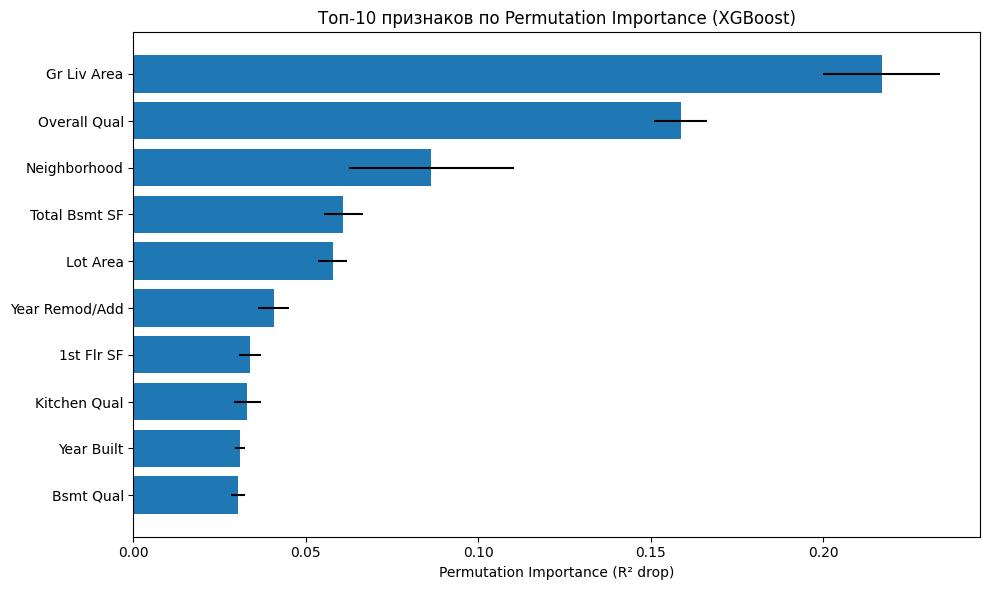


Топ-5 самых важных признаков:
1. Gr Liv Area
2. Overall Qual
3. Neighborhood
4. Total Bsmt SF
5. Lot Area

Наименее важный признак: Exter Qual

 Качество жилья (Overall Qual) действительно оказалось важным признаком!


In [23]:
perm_result = permutation_importance(
    model, X_val, y_val,
    scoring='r2',
    n_repeats=20,
    random_state=42
)

perm_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance': perm_result.importances_mean,
    'std': perm_result.importances_std
}).sort_values('importance', ascending=False)

#  топ-5 признаков 
top_5_features = perm_df['feature'].head(5).tolist()

# `worst_feature` название признака с НАИМЕНЬШЕЙ важностью
worst_feature = perm_df.loc[perm_df['importance'].idxmin(), 'feature']

# 6. Визуализируйте результаты (топ-10 признаков)
top_10 = perm_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10['feature'][::-1], top_10['importance'][::-1], xerr=top_10['std'][::-1])
plt.xlabel('Permutation Importance (R² drop)')
plt.title('Топ-10 признаков по Permutation Importance (XGBoost)')
plt.tight_layout()
plt.show()

# Код для проверки (не изменяйте):
print("\nТоп-5 самых важных признаков:")
for i, feature in enumerate(top_5_features, 1):
    print(f"{i}. {feature}")

print(f"\nНаименее важный признак: {worst_feature}")

if 'Overall Qual' in top_5_features:
    print("\n Качество жилья (Overall Qual) действительно оказалось важным признаком!")
else:
    print("\n  Обратите внимание: качество жилья не вошло в топ-5. Проверьте расчеты.")

### Пример SHAP Values для оценки важности

In [ ]:
# Выберем числовые признаки для простоты примера
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('SalePrice', errors='ignore')
X = df[numeric_cols].fillna(df[numeric_cols].median())
y = df['SalePrice']

# Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучим модель градиентного бустинга
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Оценим качество модели
y_pred = model.predict(X_test)
print(f"R² на тесте: {r2_score(y_test, y_pred):.3f}")
print(f"MSE на тесте: {mean_squared_error(y_test, y_pred):.0f}")

R² на тесте: 0.873
MSE на тесте: 741131334


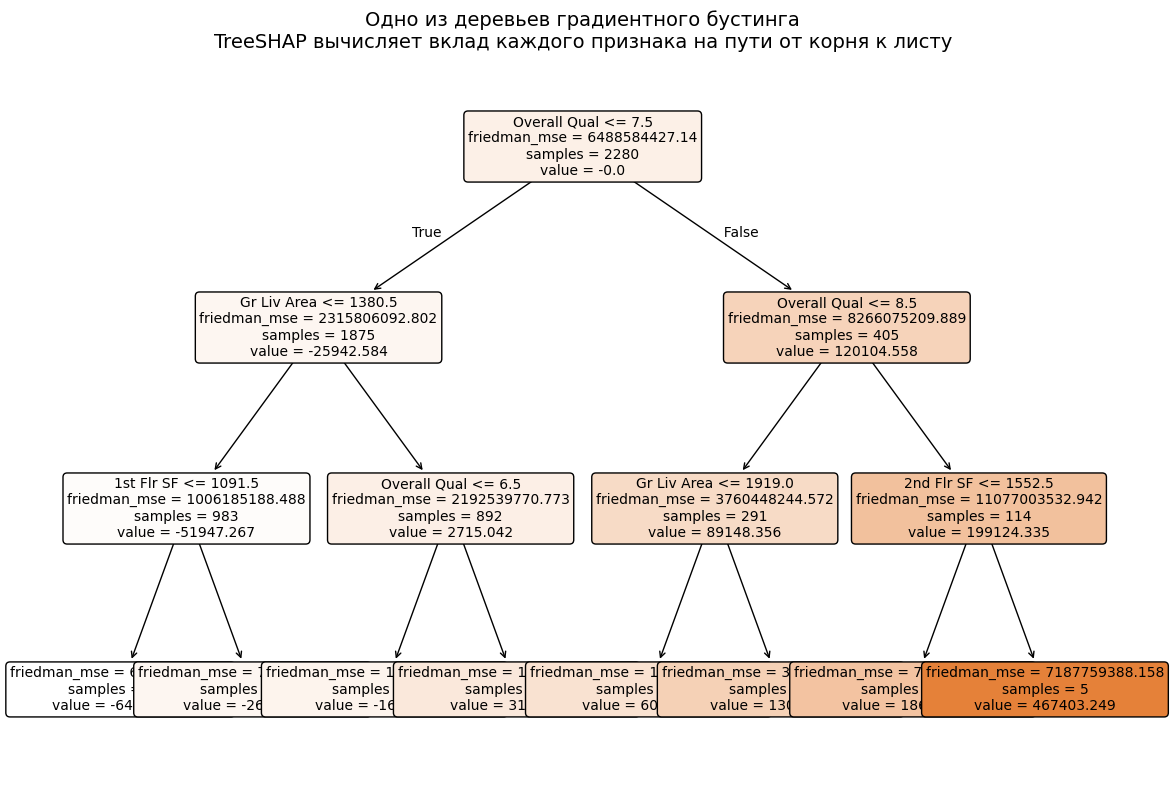

Размерность SHAP-значений: (570, 8)
Количество объектов: 570
Количество признаков: 8


In [30]:


# Создаём explainer и вычисляем SHAP-значения
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plot_tree(model.estimators_[0][0],  # первое дерево первого estimator
          feature_names=X_test.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Одно из деревьев градиентного бустинга\nTreeSHAP вычисляет вклад каждого признака на пути от корня к листу", 
          fontsize=14)
plt.tight_layout()
plt.show()

# Посмотрим на структуру результата
print(f"Размерность SHAP-значений: {shap_values.shape}")
print(f"Количество объектов: {shap_values.shape[0]}")
print(f"Количество признаков: {shap_values.shape[1]}")

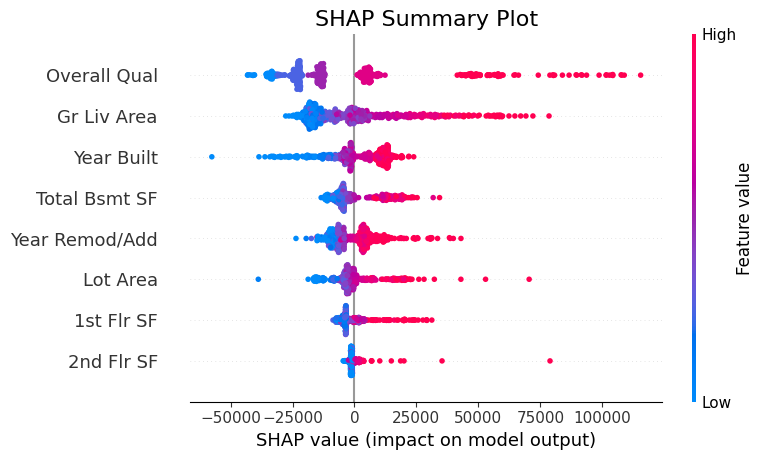

In [31]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

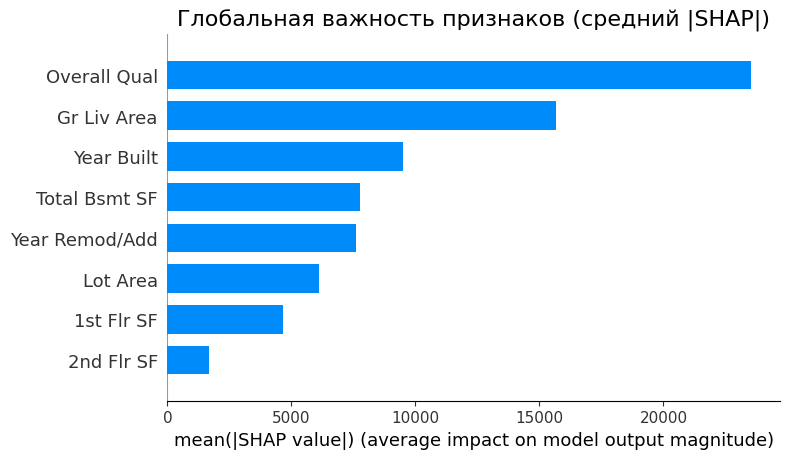

In [32]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Глобальная важность признаков (средний |SHAP|)", fontsize=16)
plt.tight_layout()
plt.show()

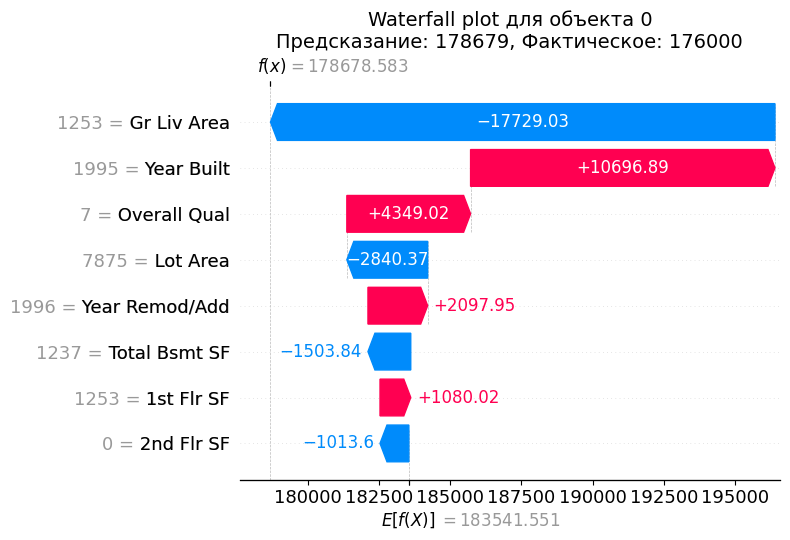

In [33]:
shap.waterfall_plot(shap.Explanation(values=shap_values[0], 
                                    base_values=explainer.expected_value,
                                    data=X_test.iloc[0],
                                    feature_names=X_test.columns.tolist()),
                    max_display=10, show=False)
plt.title(f"Waterfall plot для объекта 0\nПредсказание: {y_pred[0]:.0f}, Фактическое: {y_test.iloc[0]:.0f}", fontsize=14)
plt.tight_layout()
plt.show()

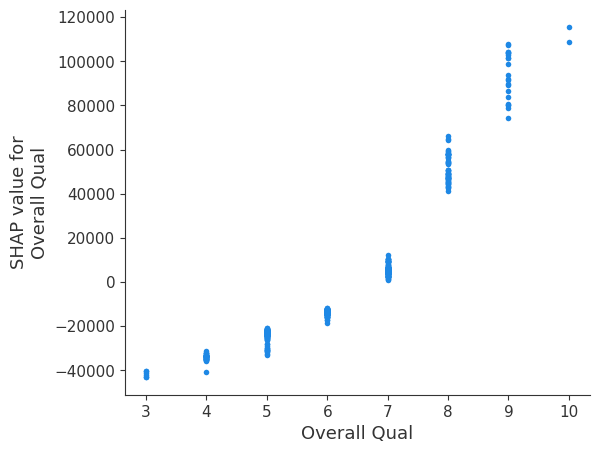

In [34]:
shap.dependence_plot("Overall Qual", shap_values, X_test, interaction_index=None)

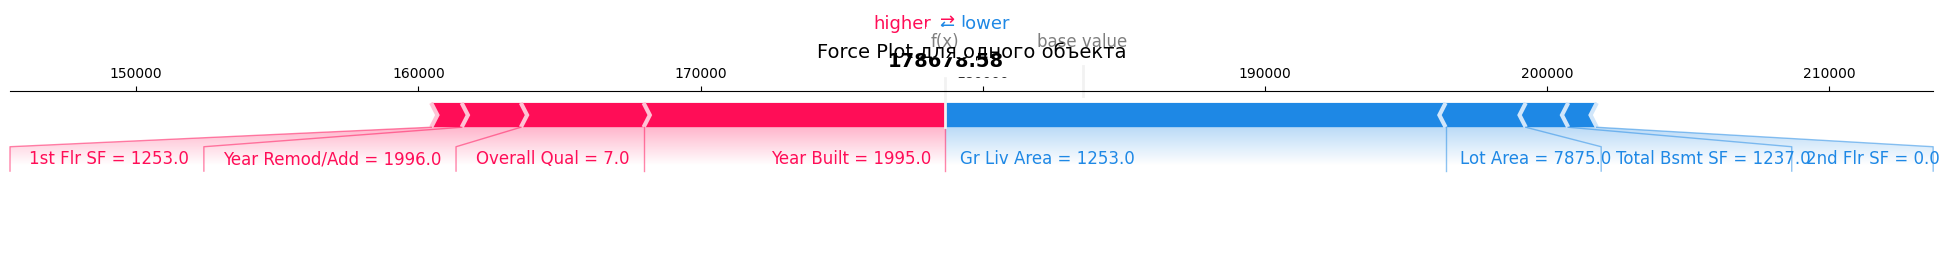

In [35]:
# Force Plot для первого объекта
shap.force_plot(explainer.expected_value, 
                shap_values[0], 
                X_test.iloc[0],
                matplotlib=True, 
                show=False)
plt.title("Force Plot для одного объекта", fontsize=14)
plt.tight_layout()
plt.show()

### Сравнение библиотек градиентного бустинга

In [ ]:
print(f"Размер датасета: {df.shape}")
print(f"Целевая переменная: SalePrice")

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('SalePrice', errors='ignore')
X = df[numeric_cols].fillna(df[numeric_cols].median())
y = df['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")
print(f"Признаки: {list(X_train.columns)}")

Размер датасета: (2850, 13)
Целевая переменная: SalePrice
Размер обучающей выборки: (2280, 8)
Размер валидационной выборки: (570, 8)
Признаки: ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Year Built', 'Year Remod/Add', 'Lot Area']


In [ ]:
# CatBoost

catboost_model = CatBoostRegressor(learning_rate=0.1, iterations=100, depth=6, random_state=42, verbose=0)

start_time = time.time()

catboost_model.fit(X_train, y_train)

catboost_train_time = time.time() - start_time

y_pred_catboost = catboost_model.predict(X_val)

rmse_catboost = root_mean_squared_error(y_val, y_pred_catboost)
mae_catboost = mean_absolute_error(y_val, y_pred_catboost)
r2_catboost = r2_score(y_val, y_pred_catboost)

print(f"CatBoost обучен за {catboost_train_time:.2f} секунд")
print(f"RMSE: {rmse_catboost:.2f}")
print(f"MAE: {mae_catboost:.2f}")
print(f"R²: {r2_catboost:.4f}")

CatBoost обучен за 0.06 секунд
RMSE: 25906.17
MAE: 16994.82
R²: 0.8849


In [ ]:
# XGBoost

xgboost_model = XGBRegressor(learning_rate=0.1, n_estimators=100, max_depth=6, random_state=42)


start_time = time.time()

xgboost_model.fit(X_train, y_train)

xgboost_train_time = time.time() - start_time

y_pred_xgboost = xgboost_model.predict(X_val)

rmse_xgboost = root_mean_squared_error(y_val, y_pred_xgboost)
mae_xgboost = mean_absolute_error(y_val, y_pred_xgboost)
r2_xgboost = r2_score(y_val, y_pred_xgboost)

print(f"XGBoost обучен за {xgboost_train_time:.2f} секунд")
print(f"RMSE: {rmse_xgboost:.2f}")
print(f"MAE: {mae_xgboost:.2f}")
print(f"R²: {r2_xgboost:.4f}")


XGBoost обучен за 0.19 секунд
RMSE: 26466.23
MAE: 17712.20
R²: 0.8799


In [43]:
# LightGBM
# 1. Создайте модель LGBMRegressor с параметрами:
#    learning_rate=0.1, n_estimators=100, max_depth=6, random_state=42, verbose=-1
lgbm_model = LGBMRegressor(learning_rate=0.1, n_estimators=100, max_depth=6, random_state=42, verbose=-1)

# 2. Замерьте время обучения
start_time = time.time()

# 3. Обучите модель на X_train и y_train
lgbm_model.fit(X_train, y_train)

lgbm_train_time = time.time() - start_time

# 4. Получите предсказания на валидационной выборке
y_pred_lgbm = lgbm_model.predict(X_val)

# 5. Вычислите метрики
rmse_lgbm = np.sqrt(mean_squared_error(y_val, y_pred_lgbm))
mae_lgbm = mean_absolute_error(y_val, y_pred_lgbm)
r2_lgbm = r2_score(y_val, y_pred_lgbm)

print(f"LightGBM обучен за {lgbm_train_time:.2f} секунд")
print(f"RMSE: {rmse_lgbm:.2f}")
print(f"MAE: {mae_lgbm:.2f}")
print(f"R²: {r2_lgbm:.4f}")

LightGBM обучен за 0.24 секунд
RMSE: 25859.17
MAE: 17131.06
R²: 0.8853


### Сравнение качества моделей

In [44]:
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# 1. Рассчитайте метрики для каждой модели
rmse_catboost, mae_catboost, r2_catboost = calculate_metrics(y_val, y_pred_catboost)
rmse_xgboost, mae_xgboost, r2_xgboost = calculate_metrics(y_val, y_pred_xgboost)
rmse_lgbm, mae_lgbm, r2_lgbm = calculate_metrics(y_val, y_pred_lgbm)

# 2. Создайте DataFrame с результатами
results_df = pd.DataFrame({
    'Модель': ['CatBoost', 'XGBoost', 'LightGBM'],
    'RMSE': [rmse_catboost, rmse_xgboost, rmse_lgbm],
    'MAE': [mae_catboost, mae_xgboost, mae_lgbm],
    'R²': [r2_catboost, r2_xgboost, r2_lgbm],
    'Время обучения (сек)': [catboost_train_time, xgboost_train_time, lgbm_train_time]
})

# 3. Выведите таблицу результатов
print("=== Сравнение моделей ===")
print(results_df.to_string(index=False))

=== Сравнение моделей ===
  Модель         RMSE          MAE       R²  Время обучения (сек)
CatBoost 25906.171356 16994.819034 0.884911              0.060123
 XGBoost 26466.232070 17712.199219 0.879881              0.185216
LightGBM 25859.166373 17131.062143 0.885329              0.242488


### Анализ важности признаков

Топ-10 важнейших признаков:
       feature  importance
      Lot Area         296
   Gr Liv Area         280
 Total Bsmt SF         191
    Year Built         191
    1st Flr SF         185
Year Remod/Add         152
    2nd Flr SF         149
  Overall Qual         125


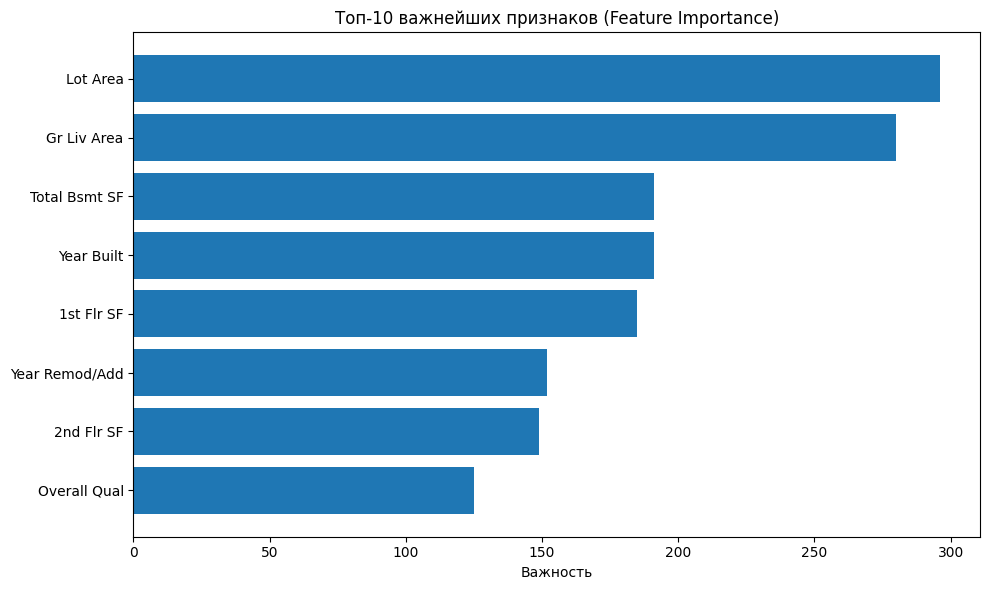

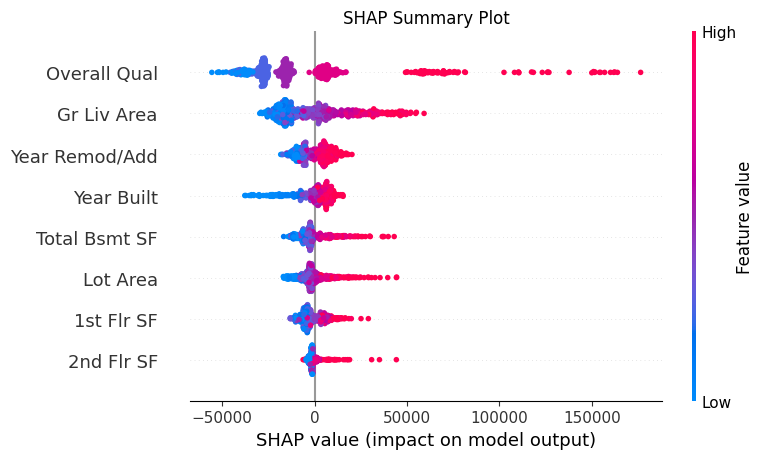

In [ ]:
# 1. Извлеките важность признаков из лучшей модели
best_model = lgbm_model
feature_importance = best_model.feature_importances_

# 2. Создайте DataFrame с важностями и отсортируйте по убыванию
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# 3. Выведите топ-10 важнейших признаков
top_10_features = importance_df.head(10)
print("Топ-10 важнейших признаков:")
print(top_10_features.to_string(index=False))

# 4. Постройте столбчатую диаграмму топ-10 признаков
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['feature'][::-1], top_10_features['importance'][::-1])
plt.xlabel('Важность')
plt.title('Топ-10 важнейших признаков (Feature Importance)')
plt.tight_layout()
plt.show()

# 5. Вычислите SHAP values и постройте summary plot
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


RMSE стекинга: 33095.72
R^2 стекинга:  0.8246


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
